# ETL e Validação - Comex Stat 2025

Validação de qualidade dos dados de exportação do Comex Stat antes do Power BI.

**Verificações:** nulos, duplicados, tipos (CO_NCM como texto).

**Resultados:** ✅ Todos os CSVs carregados com encoding correto, ✅ nenhum valor nulo, ✅ nenhuma duplicata.

In [ ]:
import pandas as pd

# lendo o arquivo
df = pd.read_csv('EXP_2025.csv', sep=';', encoding='latin-1')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1709746 entries, 0 to 1709745
Data columns (total 11 columns):
 #   Column      Dtype 
---  ------      ----- 
 0   CO_ANO      int64 
 1   CO_MES      int64 
 2   CO_NCM      int64 
 3   CO_UNID     int64 
 4   CO_PAIS     int64 
 5   SG_UF_NCM   object
 6   CO_VIA      int64 
 7   CO_URF      int64 
 8   QT_ESTAT    int64 
 9   KG_LIQUIDO  int64 
 10  VL_FOB      int64 
dtypes: int64(10), object(1)
memory usage: 143.5+ MB


In [ ]:
df.columns

Index(['CO_ANO', 'CO_MES', 'CO_NCM', 'CO_UNID', 'CO_PAIS', 'SG_UF_NCM',
       'CO_VIA', 'CO_URF', 'QT_ESTAT', 'KG_LIQUIDO', 'VL_FOB'],
      dtype='object')

In [ ]:
df.head()

,CO_ANO,CO_MES,CO_NCM,CO_UNID,CO_PAIS,SG_UF_NCM,CO_VIA,CO_URF,QT_ESTAT,KG_LIQUIDO,VL_FOB
0,2025,8,71039900,19,687,RS,4,817700,61690,13,203
1,2025,12,2071412,10,741,SC,1,817800,83835,83835,111324
2,2025,11,33059000,10,767,SP,4,817600,792,753,22012
3,2025,11,56031330,10,845,SP,7,1017701,2437,2437,8458
4,2025,6,21069090,10,365,SP,1,817800,4800,4800,17304


In [ ]:
df.describe()

,CO_ANO,CO_MES,CO_NCM,CO_UNID,CO_PAIS,CO_VIA,CO_URF,QT_ESTAT,KG_LIQUIDO,VL_FOB
count,1709746.0,1.709746e+06,1.709746e+06,1.709746e+06,1.709746e+06,1.709746e+06,1.709746e+06,1.709746e+06,1.709746e+06,1.709746e+06
mean,2025.0,6.680403e+00,4.940779e+07,1.065404e+01,3.873270e+02,2.999435e+00,8.003287e+05,3.524104e+05,5.028979e+05,2.037019e+05
std,0.0,3.417686e+00,3.208940e+07,1.711613e+00,2.372586e+02,2.633118e+00,3.609370e+05,3.778164e+07,3.858018e+07,4.784208e+06
min,2025.0,1.000000e+00,1.012100e+06,1.000000e+01,1.300000e+01,0.000000e+00,1.176000e+05,0.000000e+00,0.000000e+00,0.000000e+00
25%,2025.0,4.000000e+00,1.905320e+07,1.000000e+01,1.690000e+02,1.000000e+00,8.176000e+05,5.000000e+00,5.000000e+00,8.800000e+01
50%,2025.0,7.000000e+00,4.504900e+07,1.000000e+01,3.720000e+02,1.000000e+00,8.178000e+05,3.200000e+01,3.900000e+01,7.650000e+02
75%,2025.0,1.000000e+01,8.424899e+07,1.100000e+01,5.860000e+02,4.000000e+00,9.178000e+05,5.210000e+02,8.850000e+02,1.155000e+04
max,2025.0,1.200000e+01,9.706900e+07,2.200000e+01,8.900000e+02,1.500000e+01,9.999999e+06,1.369865e+10,1.369865e+10,1.009546e+09


In [ ]:
df['CO_NCM'].value_counts().head(10)

,count
CO_NCM,
2023000,9920
39269090,7191
73181500,6007
40169300,5922
2032900,5919
73269090,5695
2071422,5245
87089990,4960
2071412,4766


In [ ]:
# valores nulos
df.isna().sum()

,0
CO_ANO,0
CO_MES,0
CO_NCM,0
CO_UNID,0
CO_PAIS,0
SG_UF_NCM,0
CO_VIA,0
CO_URF,0
QT_ESTAT,0
KG_LIQUIDO,0


In [ ]:
# Verificar linhas completamente duplicadas
linhas_duplicadas_totais = df.duplicated().sum()
print(f"Linhas IDÊNTICAS em todas colunas: {linhas_duplicadas_totais}")

Linhas IDÊNTICAS em todas colunas: 0


In [ ]:
# exemplo: qual modalidade transporta o maior volume (em kg) total?
df.groupby('CO_VIA')['KG_LIQUIDO'].mean().sort_values(ascending=False)

,KG_LIQUIDO
CO_VIA,
2,1.036238e+08
3,1.727319e+06
1,9.171109e+05
6,3.483918e+05
0,8.495304e+04
7,2.846298e+04
15,7.685178e+03
9,5.680243e+03
4,5.679702e+03


In [ ]:
df.groupby('CO_PAIS')['VL_FOB'].mean().sort_values(ascending=False)

,VL_FOB
CO_PAIS,
372,6.476294e+06
160,3.375675e+06
59,1.846007e+06
531,1.621627e+06
81,1.441478e+06
...,...
710,5.640000e+02
697,3.912627e+02
187,1.270000e+02


In [ ]:
# paises com maior ticket médio (depois relacionar com tabela auxiliar para saber qual países são esses)
ticket_medio = df.groupby('CO_PAIS')['VL_FOB'].mean().sort_values(ascending=False)

top_paises_ticket_medio = ticket_medio.head(10)
print(top_paises_ticket_medio)

CO_PAIS
372    6.476294e+06
160    3.375675e+06
59     1.846007e+06
531    1.621627e+06
81     1.441478e+06
866    1.363998e+06
576    1.169746e+06
379    1.054773e+06
369    1.007919e+06
556    8.817298e+05
Name: VL_FOB, dtype: float64


/tmp/ipykernel_15502/255757436.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_paises.index, y=top_10_paises.values, palette='viridis') # palette='viridis' fica bom tbm


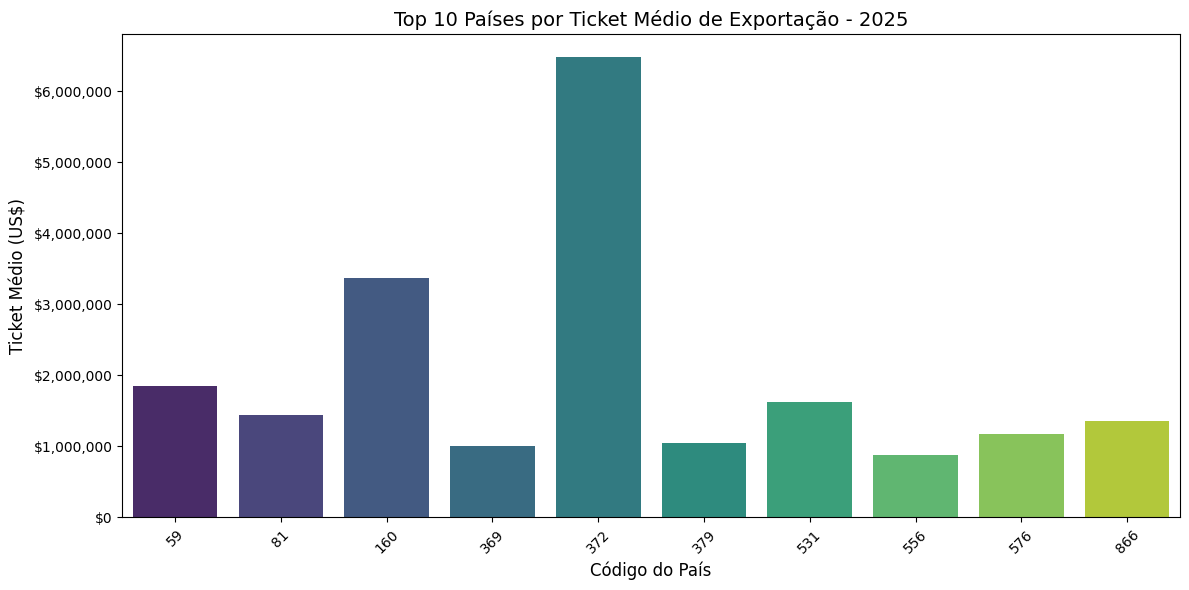

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# top 10 países por ticket médio
top_10_paises = df.groupby('CO_PAIS')['VL_FOB'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_10_paises.index, y=top_10_paises.values, palette='viridis') # palette='viridis' fica bom tbm

plt.title('Top 10 Países por Ticket Médio de Exportação - 2025', fontsize=14)
plt.xlabel('Código do País', fontsize=12)
plt.ylabel('Ticket Médio (US$)', fontsize=12)
plt.xticks(rotation=45)

#tira a notação do eixo y, mas sem formatação
#plt.ticklabel_format(axis='y', style='plain')

# formata y com $
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))


plt.tight_layout()
plt.show()

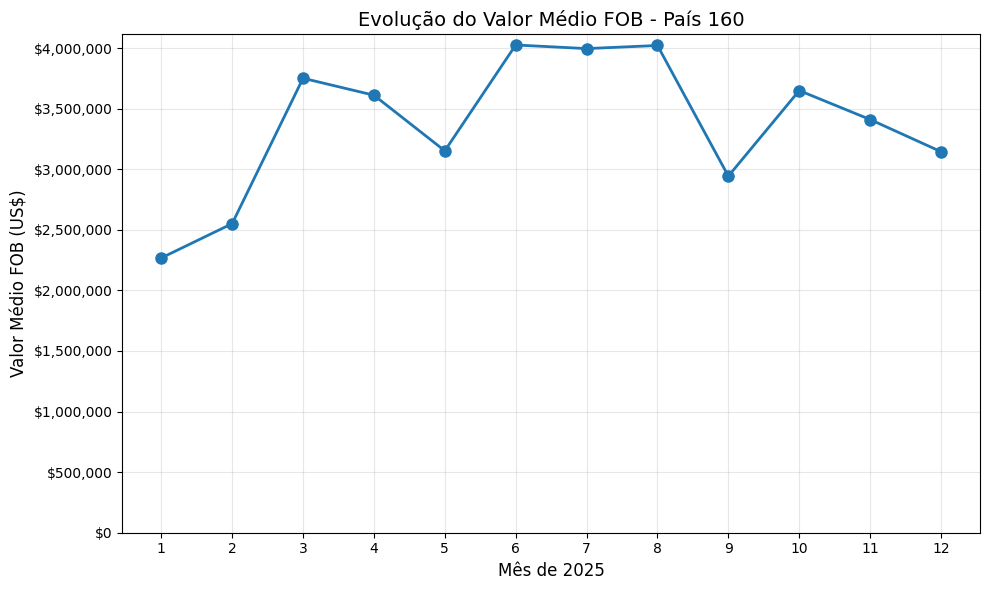

In [ ]:
# China = 160, Ira = 372, Equador = 59
pais_especifico = 160
df_pais = df[df['CO_PAIS'] == pais_especifico]

media_mensal = df_pais.groupby('CO_MES')['VL_FOB'].mean()

plt.figure(figsize=(10, 6))
plt.plot(media_mensal.index, media_mensal.values, marker='o', linewidth=2, markersize=8)

plt.title(f'Evolução do Valor Médio FOB - País {pais_especifico}', fontsize=14)
plt.xlabel('Mês de 2025', fontsize=12)
plt.ylabel('Valor Médio FOB (US$)', fontsize=12)

# define valores que aparecem no eixo x (meses)
plt.xticks(range(1, 13))
# add como segundp parametro de range(,) para mostrar nomes do meses: ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']

# adciona linhas de grade, alpha determina transparencia
plt.grid(True, alpha=0.3)

# faz eixo y começar no 0 (acho menos tendencioso começando no 0)
plt.ylim(0, None)

# formatando $
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

# CARREGANDO TABELAS AUXILIARES

In [ ]:
# Carregar tabela de NCM
ncm = pd.read_csv('NCM_TABELAS_AUXILIARES.csv', sep=';', encoding='utf-8-sig')
print("TABELA NCM")
print(f"Formato: {ncm.shape}")
print(f"Colunas: {ncm.columns.tolist()}")

# Carregar tabela de UF
uf = pd.read_csv('UF_TABELAS_AUXILIARES.csv', sep=';', encoding='utf-8-sig')
print("TABELA UF")
print(f"Formato: {uf.shape}")
print(f"Colunas: {uf.columns.tolist()}")

# Carregar tabela de VIA
via = pd.read_csv('VIA_TABELAS_AUXILIARES.csv', sep=';', encoding='utf-8-sig')
print("TABELA VIA")
print(f"Formato: {via.shape}")
print(f"Colunas: {via.columns.tolist()}")

# Carregar tabela de PAIS
pais = pd.read_csv('PAIS_TABELAS_AUXILIARES.csv', sep=';', encoding='latin-1')
print("TABELA PAIS")
print(f"Formato: {pais.shape}")
print(f"Colunas: {pais.columns.tolist()}")

TABELA NCM
Formato: (13744, 3)
Colunas: ['Código NCM', 'Descrição NCM', 'Unidade estatística']
TABELA UF
Formato: (34, 2)
Colunas: ['Sigla', 'Nome']
TABELA VIA
Formato: (17, 1)
Colunas: ['Via']
TABELA PAIS
Formato: (281, 6)
Colunas: ['CO_PAIS', 'CO_PAIS_ISON3', 'CO_PAIS_ISOA3', 'NO_PAIS', 'NO_PAIS_ING', 'NO_PAIS_ESP']


In [ ]:
display(ncm.head())
display(uf.head())
display(via.head())
display(pais.head())

,Código NCM,Descrição NCM,Unidade estatística
0,60063130,"Outros tecidos de malha, de fibras sintéticas,...",QUILOGRAMA LIQUIDO
1,60063190,"Outros tecidos de malha, de fibras sintéticas,...",QUILOGRAMA LIQUIDO
2,60063200,"Outros tecidos de malha, de fibras sintéticas,...",QUILOGRAMA LIQUIDO
3,60063210,"Outros tecidos de malha, de fibras sintéticas,...",QUILOGRAMA LIQUIDO
4,60063220,"Outros tecidos de malha, de fibras sintéticas,...",QUILOGRAMA LIQUIDO


,Sigla,Nome
0,PE,Pernambuco
1,MT,Mato Grosso
2,PI,Piauí
3,ND,Não Declarada
4,MS,Mato Grosso do Sul


,Via
0,VIA NAO DECLARADA
1,MARITIMA
2,FLUVIAL
3,LACUSTRE
4,AEREA


,CO_PAIS,CO_PAIS_ISON3,CO_PAIS_ISOA3,NO_PAIS,NO_PAIS_ING,NO_PAIS_ESP
0,0,898,ZZZ,Não Definido,Not defined,No definido
1,13,4,AFG,Afeganistão,Afghanistan,Afganistan
2,15,248,ALA,"Aland, Ilhas",Aland Islands,"Alans, Islas"
3,17,8,ALB,Albânia,Albania,Albania
4,20,724,ESP,"Alboran-Perejil, Ilhas","Alboran-Perejil, Islands","Alboran-Perejil, Islas"


In [ ]:
# Salvar as tabelas separadas para usar no Power BI
pais.to_csv('dim_paises.csv', index=False, encoding='utf-8-sig')
uf.to_csv('dim_uf.csv', index=False, encoding='utf-8-sig')
ncm.to_csv('dim_ncm.csv', index=False, encoding='utf-8-sig')
via.to_csv('dim_via.csv', index=False, encoding='utf-8-sig')
df.to_csv('fato_exportacoes.csv', index=False, encoding='utf-8-sig')

✅ Arquivos exportados para usar no Power BI!


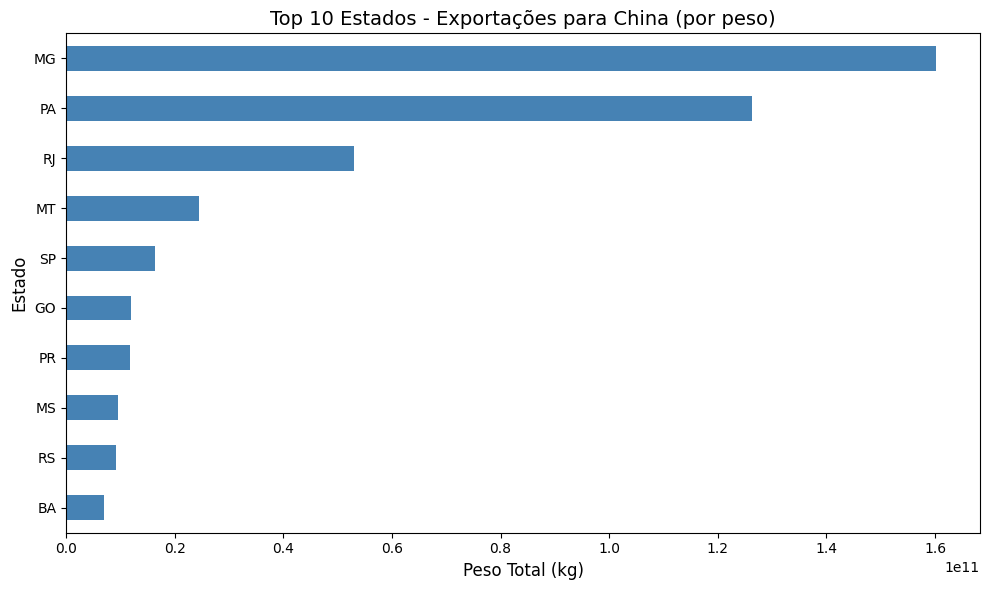

SG_UF_NCM
MG    160248140263
PA    126371698644
RJ     53039216357
MT     24503027032
SP     16444921374
GO     11974274709
PR     11856881394
MS      9576257216
RS      9283849899
BA      7044714654
Name: KG_LIQUIDO, dtype: int64


In [ ]:
# Filtrar China e somar peso por estado (conferindo coerencia com o que achei no BI)
china_estados = df[df['CO_PAIS'] == 160].groupby('SG_UF_NCM')['KG_LIQUIDO'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))

china_estados.head(10).plot(kind='barh', color='steelblue')
plt.title('Top 10 Estados - Exportações para China (por peso)', fontsize=14)
plt.xlabel('Peso Total (kg)', fontsize=12)
plt.ylabel('Estado', fontsize=12)
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

print(china_estados.head(10))

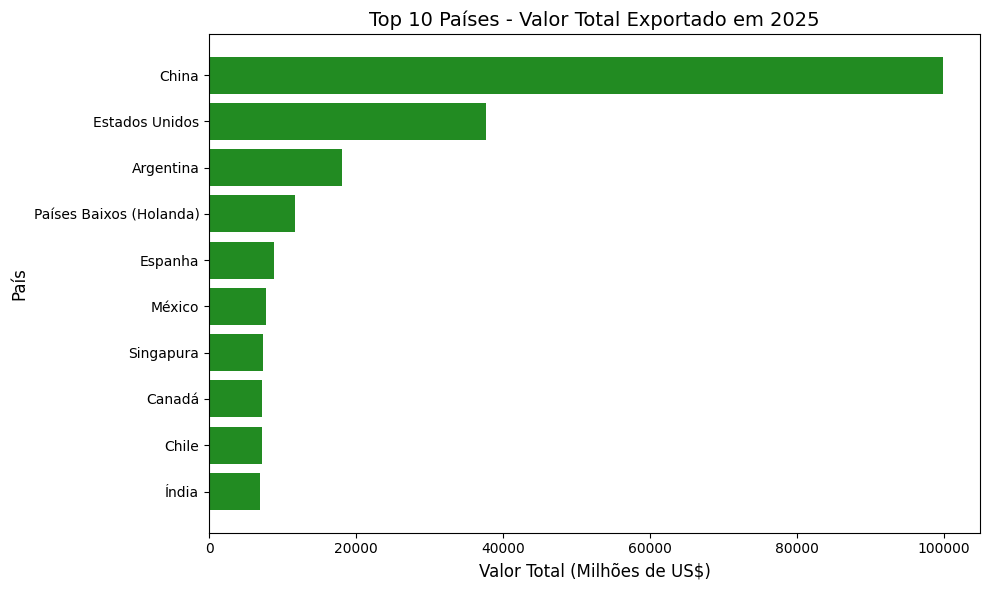

                     NO_PAIS       VL_FOB
45                     China  99940244710
71            Estados Unidos  37682246914
12                 Argentina  18105303283
164  Países Baixos (Holanda)  11726736048
68                   Espanha   8783248496
140                   México   7728866863
203                Singapura   7353096562
41                    Canadá   7251870870
44                     Chile   7176227117
104                    Índia   6865880767

Total exportado: R$ 348.28 bilhões


In [ ]:
# Somar valor FOB por país
pais_valor = df.groupby('CO_PAIS')['VL_FOB'].sum().sort_values(ascending=False)

# Juntar com nomes dos países
pais_nomes = pais.merge(pais_valor.reset_index(), on='CO_PAIS', how='inner')
pais_nomes = pais_nomes.sort_values('VL_FOB', ascending=False)

# Top 10
top_paises = pais_nomes.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_paises['NO_PAIS'], top_paises['VL_FOB'] / 1e6, color='forestgreen')
plt.title('Top 10 Países - Valor Total Exportado em 2025', fontsize=14)
plt.xlabel('Valor Total (Milhões de US$)', fontsize=12)
plt.ylabel('País', fontsize=12)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(top_paises[['NO_PAIS', 'VL_FOB']])
print(f"\nTotal exportado: R$ {pais_nomes['VL_FOB'].sum() / 1e9:.2f} bilhões")